In [1]:
import scanpy as sc
import anndata as ad
import umap
import matplotlib.pyplot as plt
from mmidas.vaegan import vae_gan

from mmidas.utils.config_tools import get_paths
from mmidas.utils.data_tools import load_data
from mmidas.utils.augmentation import get_loader


%load_ext autoreload
%autoreload 2

/home/yeganeh.marghi/miniconda3/envs/mixrep2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
toml_file = 'pyproject.toml'
device = 'cpu'
config = get_paths(toml_file=toml_file)
data_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['anndata_file']
gene_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['hvg_file']
aug_path = config['paths']['main_dir'] / config['paths']['models']
aug_file = aug_path / config['models']['augmenter']

/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/pyproject.toml
Getting files directories belong to data...
Getting files directories belong to models...


In [3]:
aug_vaegan = vae_gan(saving_folder=aug_path, device=device)
aug_vaegan.load_model(aug_file)

---> Using CPU!
Load the pre-trained augmenter model - /allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/models/RNA_augmenter_2024-12-23-16-55-27.pth


/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/mmidas/vaegan.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model = torch.load(traine

In [4]:
data = load_data(file=data_file, gene_file=gene_file) 
original_data = data['log1p']

Number of cells: 4608, Number of genes: 1827


In [5]:
data_loader = get_loader(x=original_data, batch_size=256, training=False)
aug_samples = aug_vaegan.sample_generator(dataloader=data_loader, noise=True, scale=0.1, exclude_zeros=False)

Dataloader for augmentation created!


/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_4034/2466979103.py:7: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = aug_samples_adata.concatenate(original_data_adata)


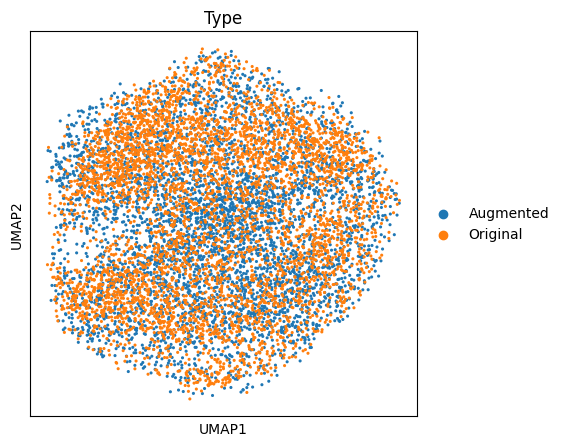

In [10]:
# Convert original_data to AnnData object
original_data_adata = ad.AnnData(X=original_data)
original_data_adata.obs['Type'] = 'Original'
aug_samples_adata = ad.AnnData(X=aug_samples)
aug_samples_adata.obs['Type'] = 'Augmented'

adata = aug_samples_adata.concatenate(original_data_adata)

sc.pp.neighbors(adata, use_rep='X', random_state=100)
sc.tl.umap(adata)
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
sc.pl.umap(adata, color='Type', ax=axs, size=20, alpha=1)

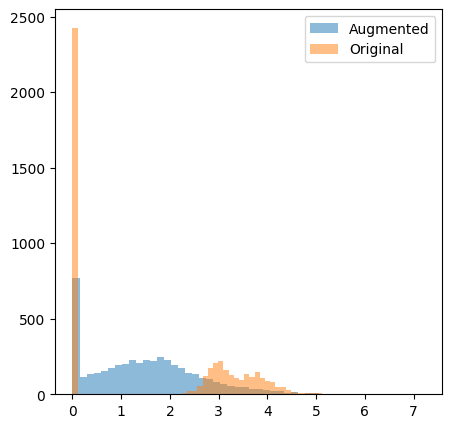

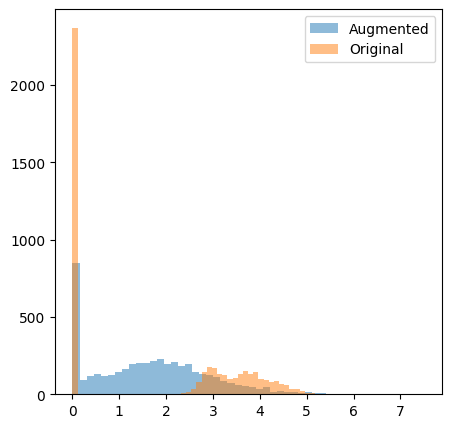

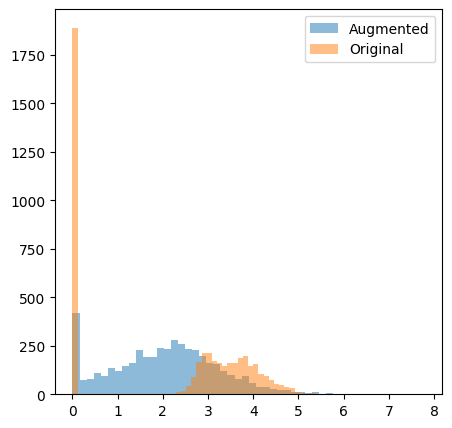

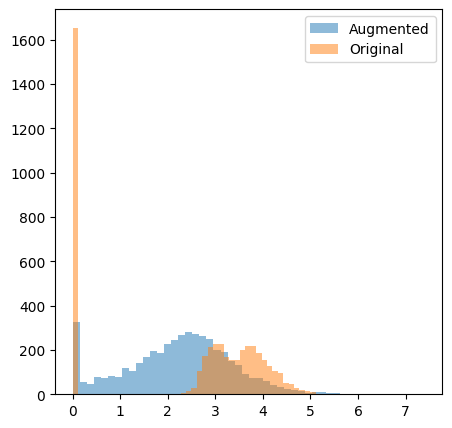

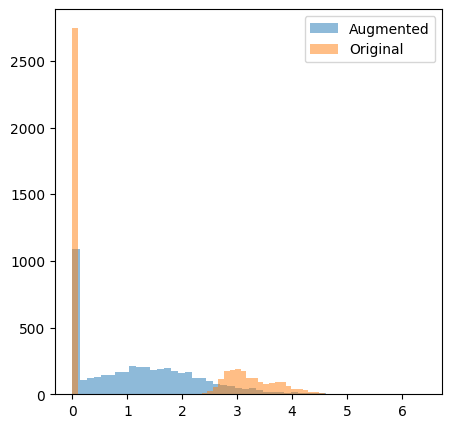

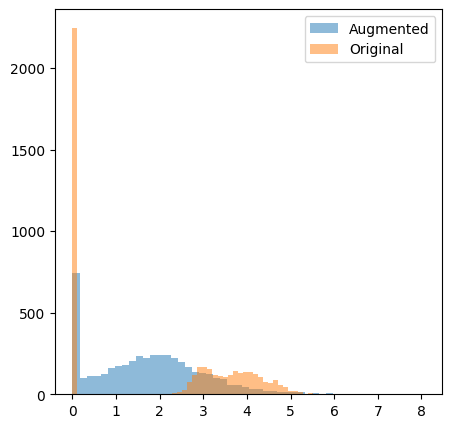

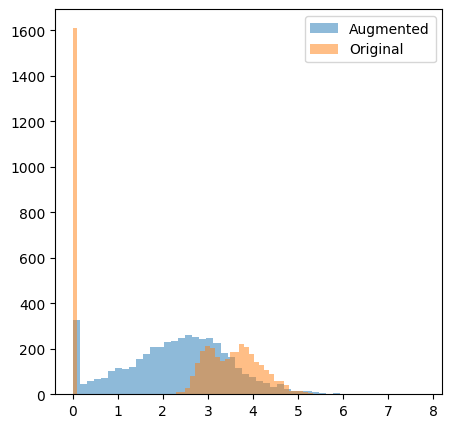

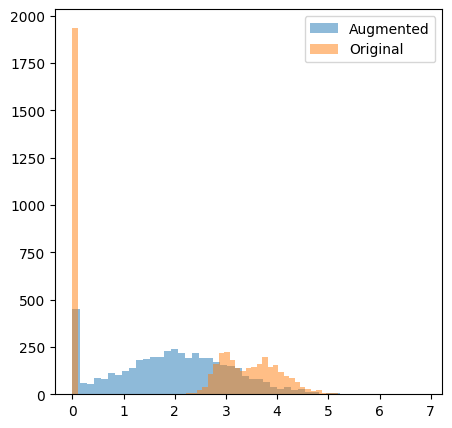

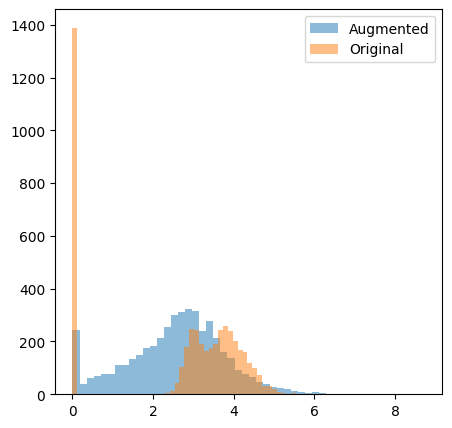

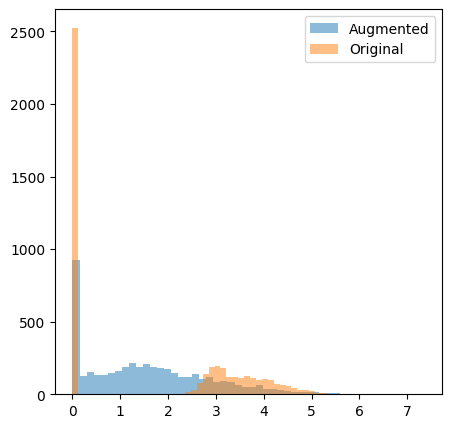

In [13]:
# Plot the original and augmented data
genes = range(10)
for gg in genes:
    fig, axs = plt.subplots(1, 1, figsize=(5, 5))
    axs.hist(aug_samples[:, gg], bins=50, alpha=0.5, label='Augmented')
    axs.hist(original_data[:, gg], bins=50, alpha=0.5, label='Original')
    plt.legend()